In [1]:
# 3-4-1 Q. Dense Block내의 각 레이어 output의 channel을 계산하는 함수를 적어보세요.

def get_channel_list():
    channel_list = []
    input_channel = 32
    growth_rate = 32
    for i in range(12): # conv layer = 12 
        channel_list.append(input_channel + growth_rate*i)
    return channel_list

get_channel_list()
# 결과가 [32, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384] 이 나오면 정상적으로 구현된 것입니다.

[32, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384]

---
### 학습내용
---
2. Ablation Study
    - Ablation Study가 무엇인지 알아봅니다.
3. CIFAR-10 데이터셋 준비
     - 학습을 위해 CIFAR-10 데이터셋을 준비합니다.
4. 블록 구성
     - VGG 기본 블록을 만들어봅니다.
5. VGG Complete Model
     - VGG 모델을 만들어봅니다.
6. VGG-16 vs VGG-19
     - VGG-16과 VGG-19를 비교실험 합니다.
--- 
### 실습목표
---

직접 VGGNet을 구현할 수 있습니다.
모델을 config에 따라서 변경 가능하도록 만들수 있습니다.
직접 실험해서 성능을 비교할 수 있습니다.

In [2]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
%pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

DATA_DIR = Path.home() / "datasets" # ~/datasets/에 데이터셋 파일 저장 

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Files already downloaded and verified
Files already downloaded and verified
Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10
Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [ ]:
# 정규화
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


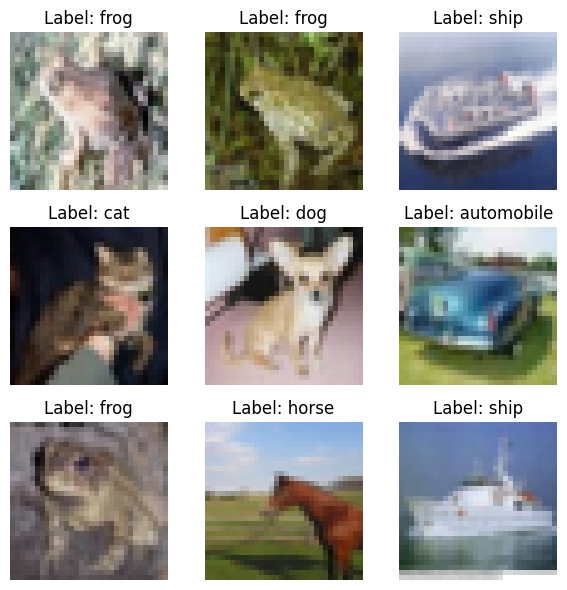

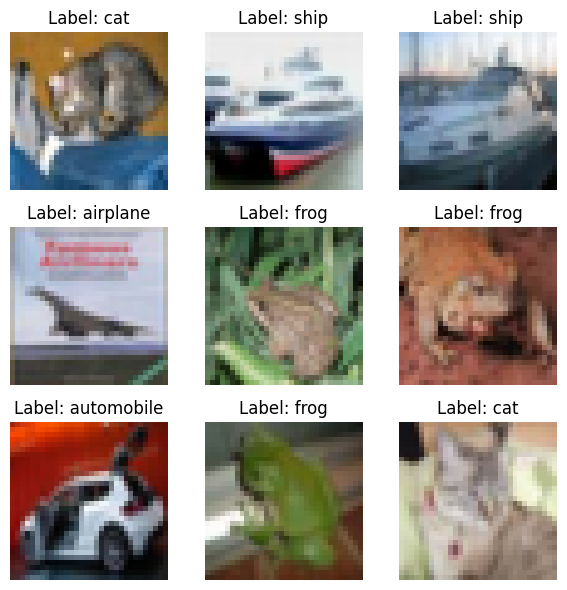

In [4]:
num_classes = len(trainset.classes)
class_names = trainset.classes

print(num_classes)
print(class_names)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

---
### VGG-16 
     블록 내의 CNN 레이어 수와 채널 수는 블록마다 달라집니다. 
     이는 VGG-16과 VGG-19에 따라서 같이 변화되므로 함수에 전달되어야 합니다.
     여기서는 각 블록 별 CNN의 수와 채널을 리스트로 전달했습니다.
---

In [5]:
# VGG 모델 자체를 생성하는 클래스입니다.

class VGG(nn.Module): 
    def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
        #블록별 Conv layer 개수(합 13 + FC 3 = 16) ▲  | 블록별 출력 채널 수 ▲ -> feature map 크기는 줄이고 채널 수는 늘리는 VGG 구조
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list), "num_cnn_list와 channel_list의 길이가 일치해야 합니다."

        layers = []
        in_channels = 3 # rgb 3채널 

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels  # 다음 블록의 입력 채널을 설정


        self.feature_extractor = nn.Sequential(*layers) # VGG 블록 묶고 feature 추출 -> 512*1*1
        self.classifier = nn.Sequential(                # 분류기(FC) 
            nn.Flatten(),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)] # 첫번째 ConV 
        for _ in range(num_cnn - 1):                                                             # 나머지 ConV
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [6]:
# 기본값을 그대로 사용해서 VGG 모델을 만들면 VGG-16이 됩니다.

vgg_16 = VGG()
summary(vgg_16)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [7]:
# VGG - 19  
# 원하는 블록의 설계에 따라 매개변수로 리스트를 전달해 줍니다.
vgg_19 = VGG(
    num_cnn_list=[2, 2, 4, 4, 4],
    channel_list=[64, 128, 256, 512, 512]
)
summary(vgg_19)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [8]:
# VGG - 13 
def build_vgg13(num_classes=10):
    return VGG(
        num_cnn_list=[2, 2, 2, 2, 2],
        channel_list=[64, 128, 256, 512, 512],
        num_classes=num_classes
    )
vgg_13 = build_vgg13()
summary(vgg_13)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─MaxPool2d: 3-15              --
│    └─Sequential: 2-4                   --
│

In [9]:
BATCH_SIZE = 256
EPOCH = 15

# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


---
### VGG - 16 훈련
---

In [10]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/home/thkim0/venv/v1/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/thkim0/venv/v1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


[1,   100] loss: 3.892
Epoch 1: Train Accuracy: 39.72%
Epoch 1: Validation Accuracy: 66.21%
[2,   100] loss: 1.924
Epoch 2: Train Accuracy: 70.70%
Epoch 2: Validation Accuracy: 74.27%
[3,   100] loss: 1.673
Epoch 3: Train Accuracy: 78.18%
Epoch 3: Validation Accuracy: 79.02%
[4,   100] loss: 1.550
Epoch 4: Train Accuracy: 81.74%
Epoch 4: Validation Accuracy: 81.00%
[5,   100] loss: 1.477
Epoch 5: Train Accuracy: 84.30%
Epoch 5: Validation Accuracy: 82.69%
[6,   100] loss: 1.405
Epoch 6: Train Accuracy: 86.29%
Epoch 6: Validation Accuracy: 82.97%
[7,   100] loss: 1.355
Epoch 7: Train Accuracy: 87.82%
Epoch 7: Validation Accuracy: 84.08%
[8,   100] loss: 1.309
Epoch 8: Train Accuracy: 89.30%
Epoch 8: Validation Accuracy: 84.30%
[9,   100] loss: 1.279
Epoch 9: Train Accuracy: 90.86%
Epoch 9: Validation Accuracy: 84.32%
[10,   100] loss: 1.226
Epoch 10: Train Accuracy: 92.21%
Epoch 10: Validation Accuracy: 84.40%
[11,   100] loss: 1.201
Epoch 11: Train Accuracy: 93.07%
Epoch 11: Validation

--- 
### VGG - 19 훈련

---

In [11]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/home/thkim0/venv/v1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1,   100] loss: 3.778
Epoch 1: Train Accuracy: 41.47%
Epoch 1: Validation Accuracy: 67.77%
[2,   100] loss: 1.827
Epoch 2: Train Accuracy: 73.65%
Epoch 2: Validation Accuracy: 77.98%
[3,   100] loss: 1.587
Epoch 3: Train Accuracy: 80.77%
Epoch 3: Validation Accuracy: 80.68%
[4,   100] loss: 1.483
Epoch 4: Train Accuracy: 83.88%
Epoch 4: Validation Accuracy: 82.43%
[5,   100] loss: 1.401
Epoch 5: Train Accuracy: 86.56%
Epoch 5: Validation Accuracy: 82.80%
[6,   100] loss: 1.360
Epoch 6: Train Accuracy: 87.96%
Epoch 6: Validation Accuracy: 84.36%
[7,   100] loss: 1.307
Epoch 7: Train Accuracy: 89.85%
Epoch 7: Validation Accuracy: 85.19%
[8,   100] loss: 1.259
Epoch 8: Train Accuracy: 91.19%
Epoch 8: Validation Accuracy: 85.83%
[9,   100] loss: 1.224
Epoch 9: Train Accuracy: 92.72%
Epoch 9: Validation Accuracy: 85.49%
[10,   100] loss: 1.194
Epoch 10: Train Accuracy: 93.62%
Epoch 10: Validation Accuracy: 86.16%
[11,   100] loss: 1.161
Epoch 11: Train Accuracy: 94.75%
Epoch 11: Validation

KeyboardInterrupt: 

---
### VGG 16/19 비교
---

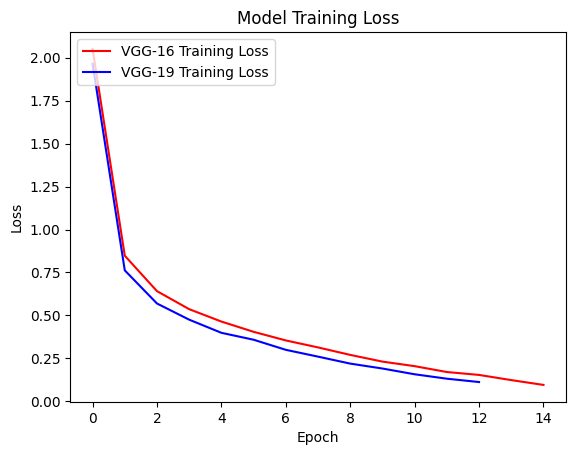

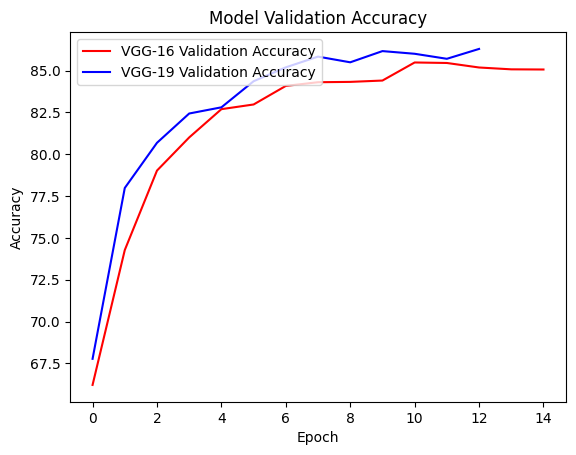

In [12]:
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label="VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label="VGG-19 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()
plt.plot(vgg_16_val_accuracy, 'r', label="VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label="VGG-19 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

---
### ResNet - Project

---

In [64]:
import torch
import torch.nn as nn

In [65]:
def conv3x3(in_channels, out_channels, stride=1): # padding 적용된 3x3 Conv Layer
  
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

In [66]:
def conv1x1(in_channels, out_channels, stride=1): # padding 적용된 1x1 Conv Layer, ResNet-50 병목구조용

    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        padding=0,
        bias=False
    )

기본 Residual Block 구현

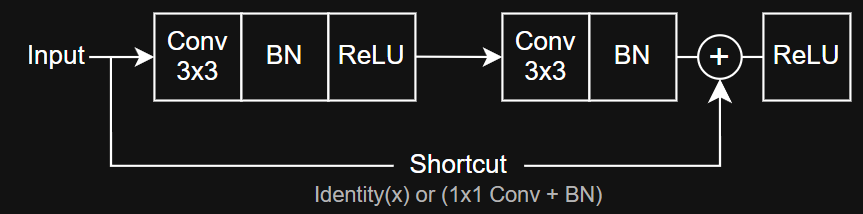

In [67]:
class BasicBlock(nn.Module):
    expansion = 1 # 출력 채널 수 = out_channels * expansion / 병목구조에선 4 

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 첫 번째 3x3 conv
        # stage가 바뀔 때(conv2_x -> conv3_x 같은 때)는 여기서 stride=2를 사용해서 feature map 크기를 줄임
        self.conv1 = conv3x3(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # 두 번째 3x3 conv
        # 두 번째 conv는 공간 크기를 더 줄이지 않으므로 stride=1
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut 경로
        # 입력과 출력의 shape이 다르면 1x1 conv로 맞춰줌
        self.downsample = None 

#           크기가 달라졌거나 / 채널 수가 달라지거나 -> shape 맞춰야함(1x1 Conv & BatchNorm)
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                conv1x1(
                    in_channels=in_channels,
                    out_channels=out_channels * self.expansion,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        # main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # shortcut path
        if self.downsample is not None:
            identity = self.downsample(x)

        # residual addition
        out = out + identity
        out = self.relu(out)

        return out

In [68]:
class PlainBasicBlock(nn.Module): # residual connection 없는 plain block 구현
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = conv3x3(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out

Bottleneck block 구현

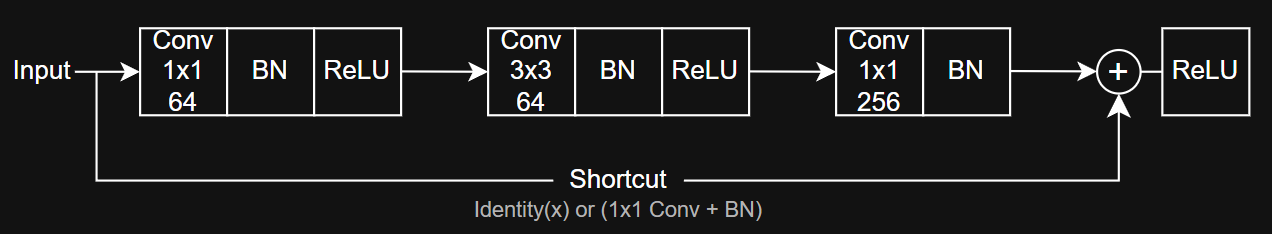

In [69]:
class BottleneckBlock(nn.Module):
    expansion = 4 # 1x1로 줄였으니까 마지막에 64*4로 늘려줘야함 

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 1x1 conv -> 채널 수 감소 
        
        self.conv1 = conv1x1(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=1
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 conv: 특징 추출 
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=stride
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 conv: 채널 수를 4배로 확장
        self.conv3 = conv1x1(
            in_channels=out_channels,
            out_channels=out_channels * self.expansion,
            stride=1
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        # shortcut 경로
        self.downsample = None

        # main path 출력과 shortcut의 shape이 다르면 1x1 conv로 맞춤
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                conv1x1(
                    in_channels=in_channels,
                    out_channels=out_channels * self.expansion,
                    stride=stride
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = x

        # main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out) # 같은 conv1을 쓰면 안되는 이유는 expansion 
        out = self.bn3(out)

        # shortcut path
        if self.downsample is not None:
            identity = self.downsample(x)

        # residual addition
        out = out + identity
        out = self.relu(out)

        return out

ResNet-50 full pre-activation용 bottleneck block 구현

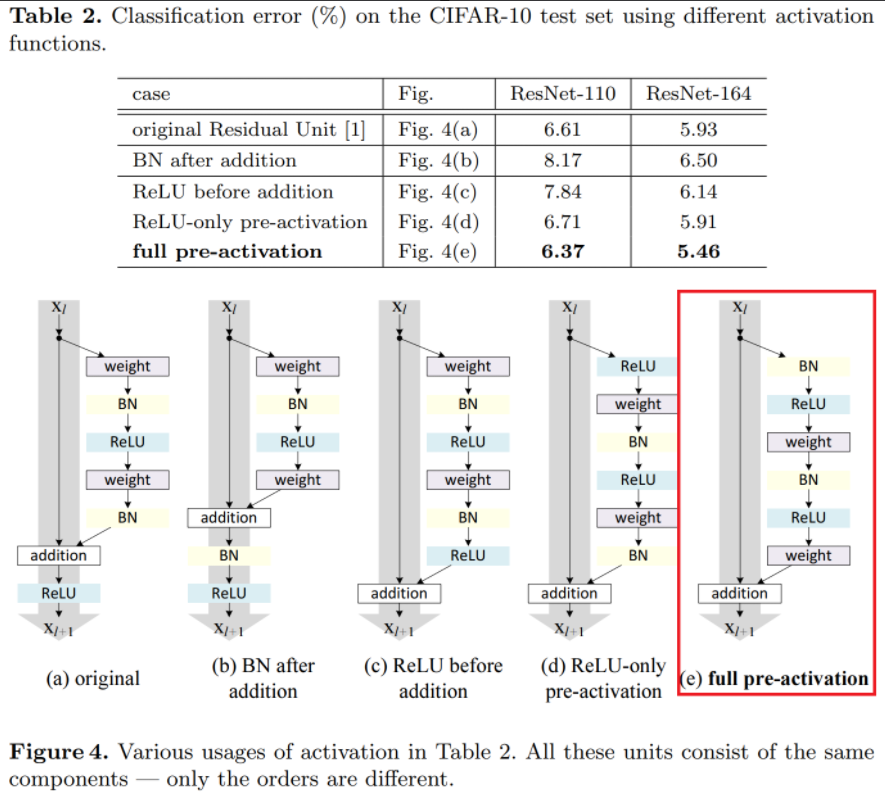

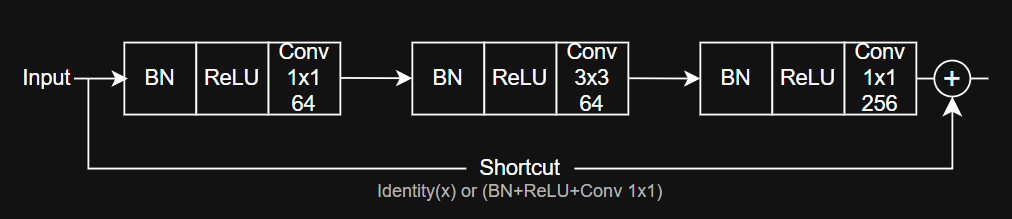


In [70]:
class PreActBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 첫 번째 pre-activation
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)

        # main branch
        self.conv1 = conv1x1(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=1
        )

        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv3x3(
            in_channels=out_channels,
            out_channels=out_channels,
            stride=stride
        )

        self.bn3 = nn.BatchNorm2d(out_channels)
        self.conv3 = conv1x1(
            in_channels=out_channels,
            out_channels=out_channels * self.expansion,
            stride=1
        )

        # shortcut branch
        # shape이 다를 때만 projection shortcut 사용
        self.downsample = None

        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = conv1x1(
                in_channels=in_channels,
                out_channels=out_channels * self.expansion,
                stride=stride
            )

    def forward(self, x):
        identity = x

        # pre-activation: x → BN → ReLU
        preact = self.bn1(x)
        preact = self.relu(preact)

        # shortcut 처리
        # shape이 다르면 BN-ReLU를 거친 preact에 1x1 conv 적용
        if self.downsample is not None:
            identity = self.downsample(preact)

        # main branch
        out = self.conv1(preact)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        # full pre-activation에서는 Add 뒤에 ReLU 없음
        out = out + identity

        return out

In [71]:
class PlainBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        mid_channels = out_channels
        final_channels = out_channels * self.expansion

        self.conv1 = nn.Conv2d(
            in_channels,
            mid_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(
            mid_channels,
            mid_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(
            mid_channels,
            final_channels,
            kernel_size=1,
            stride=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(final_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # PlainNet이므로 residual connection 없음
        # out += identity 하지 않음

        out = self.relu(out)

        return out

ResNet 기본형(?) 구현

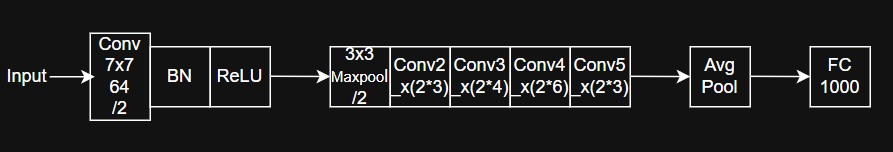

In [72]:
class ResNet(nn.Module):
    def __init__(
        self,
        block,
        layers,
        channels=[64, 128, 256, 512],
        num_classes=1000,
        preact=False
    ):
        super().__init__()

        self.in_channels = 64
        self.is_preact = block.__name__.lower().startswith("preact")

        # 첫번째 7x7 Conv
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(block, channels[0], layers[0], stride=1)
        self.layer2 = self._make_layer(block, channels[1], layers[1], stride=2)
        self.layer3 = self._make_layer(block, channels[2], layers[2], stride=2)
        self.layer4 = self._make_layer(block, channels[3], layers[3], stride=2)

        final_channels = channels[3] * block.expansion

        if self.is_preact:
            self.final_bn = nn.BatchNorm2d(final_channels)
            self.final_relu = nn.ReLU(inplace=True)
        else:
            self.final_bn = nn.Identity()
            self.final_relu = nn.Identity()

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(final_channels, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            block(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(
                block(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.final_bn(x)
        x = self.final_relu(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

ResNet Config 


- ResNet 34 -> BasicBlock
- ResNet 34 Plain -> PlainBasicBlock
- ResNet 50 -> BottleneckBlock
- ResNet 50-full-pre-activation -> PreActBottleneckBlock

In [73]:
RESNET_CONFIGS = {
    "plain34": {
        "block": PlainBasicBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet34": {
        "block": BasicBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "plainnet50": {
        "block": PlainBottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet50": {
        "block": BottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": False
    },

    "resnet50_preact": {
        "block": PreActBottleneckBlock,
        "layers": [3, 4, 6, 3],
        "channels": [64, 128, 256, 512],
        "preact": True
    }
}

In [74]:
def build_resnet(model_name="resnet34", num_classes=1000):
    config = RESNET_CONFIGS[model_name]

    return ResNet(
        block=config["block"],
        layers=config["layers"],
        channels=config["channels"],
        num_classes=num_classes,
        preact=config["preact"]
    )

In [75]:
# resnet34 구조 확인
resnet_34 = build_resnet()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

ㄴ ResNet-34 Summary : 예시와 일치함 

In [76]:
#resnet 50 구조 확인
resnet_50 = build_resnet("resnet50")
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-1              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

ㄴ ResNet-50 Summary : 예시와 일치함 

---

### Ablation Study 
    - 1. ResNet-34 vs ResNet-34 plain - Residual Connection의 효과 검증 
    - 2. ResNet-50 vs ResNet-50 plain - Bottleneck 구조에서 Residual Connection의 효과 검증
    - 3. ResNet-50 vs ResNet-50-PreAct - BN/ReLU의 위치가 바뀐 Pre-Activation ResNet 성능 시험 
    
---

In [97]:
# Dataset Load - Oxford-IIIT Pet

from pathlib import Path

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet

import numpy as np
import matplotlib.pyplot as plt
import random

In [98]:
# 기본 설정

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path.home() / "datasets"

BATCH_SIZE = 16
EPOCH = 15
IMG_SIZE = 224
NUM_CLASSES = 37

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("DATA_DIR:", DATA_DIR)

Device: cuda
DATA_DIR: /home/thkim0/datasets


In [99]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [100]:
# Oxford-IIIT Pet Dataset 생성

trainset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)

testset = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    download=True,
    transform=test_transform
)

In [101]:
trainloader = DataLoader( #dataloader 생성 
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [102]:
# 데이터셋 기본 정보 확인

image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

print("Class examples:", trainset.classes[:10])

# Batch 확인

images, labels = next(iter(trainloader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label min:", labels.min().item())
print("Label max:", labels.max().item())
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image shape: torch.Size([3, 224, 224])
Label: 0
Number of classes: 37
Train dataset size: 3680 (Shape: torch.Size([]))
Test dataset size: 3669 (Shape: torch.Size([]))
Class examples: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']
Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label min: 4
Label max: 31
Image dtype: torch.float32
Label dtype: torch.int64


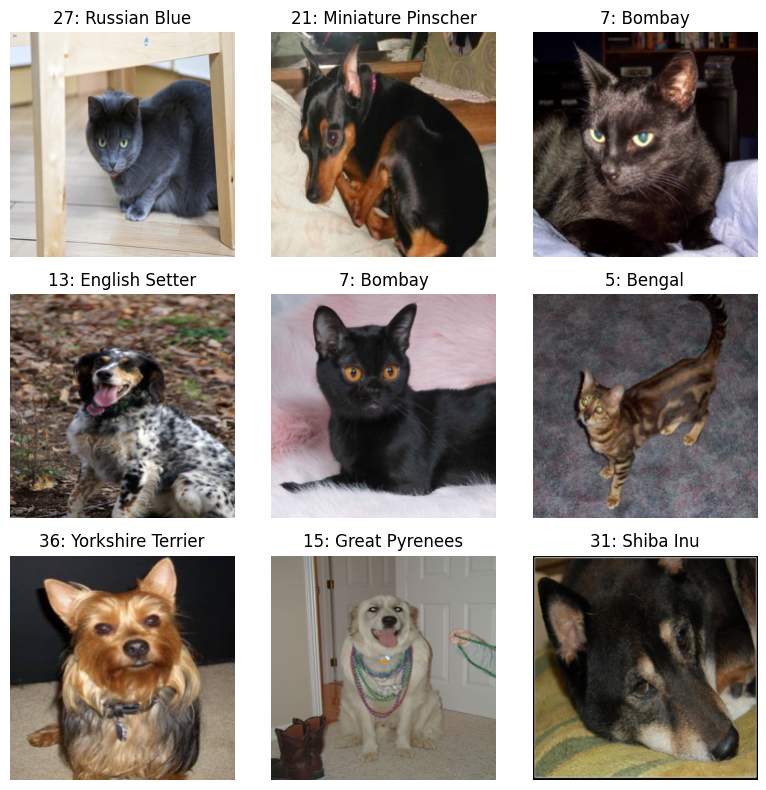

In [103]:
# 이미지 시각화

def imshow_pet(img):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

    img = img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


def show_multiple_images(dataloader, n_images=9):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow_pet(images[i])

        label_idx = labels[i].item()
        label_name = trainset.classes[label_idx]

        ax.imshow(img)
        ax.set_title(f"{label_idx}: {label_name}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_multiple_images(trainloader)

In [104]:
EXPERIMENT_MODELS = {
    "Plain-34": "plain34",
    "ResNet-34": "resnet34",
    "Plain-50": "plainnet50",
    "ResNet-50": "resnet50",
    "ResNet-50-PreAct": "resnet50_preact",
}



In [105]:
# 모델 출력 확인 
def check_model_forward(model_name, config_name):
    model = build_resnet(config_name, num_classes=NUM_CLASSES).to(device)
    model.eval()

    images, labels = next(iter(trainloader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    print(f"{model_name}")
    print(f"  Config name: {config_name}")
    print(f"  Output shape: {outputs.shape}")
    print(f"  Expected shape: torch.Size([{images.size(0)}, {NUM_CLASSES}])")
    print()


for model_name, config_name in EXPERIMENT_MODELS.items():
    check_model_forward(model_name, config_name)

Plain-34
  Config name: plain34
  Output shape: torch.Size([16, 37])
  Expected shape: torch.Size([16, 37])

ResNet-34
  Config name: resnet34
  Output shape: torch.Size([16, 37])
  Expected shape: torch.Size([16, 37])

Plain-50
  Config name: plainnet50
  Output shape: torch.Size([16, 37])
  Expected shape: torch.Size([16, 37])

ResNet-50
  Config name: resnet50
  Output shape: torch.Size([16, 37])
  Expected shape: torch.Size([16, 37])

ResNet-50-PreAct
  Config name: resnet50_preact
  Output shape: torch.Size([16, 37])
  Expected shape: torch.Size([16, 37])



 Training Function

손실함수 : CE
optimizer : Adam


In [106]:
# 학습 함수 
import torch.optim as optim

def train_one_epoch(model, trainloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    return train_loss, train_acc

In [107]:
# 평가(evaluate)
def evaluate(model, testloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    return val_loss, val_acc

In [108]:
def fit_model(model, trainloader, testloader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            trainloader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            testloader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history

실험 대상 모델:

1. Plain-34
2. ResNet-34
3. Plain-50
4. ResNet-50
5. ResNet-50-PreAct

각 모델은 동일한 dataset,batch size,epoch,learning rate,optimizer 조건에서 학습한다.  
이를 통해 모델 구조 차이에 따른 validation accuracy와 validation loss 변화를 비교할 수 있다.

ResNet-50은 `Plain-50 vs ResNet-50` 비교와 `ResNet-50 vs ResNet-50-PreAct` 비교에 모두 사용되므로 한 번만 학습한 뒤 history를 재사용한다.

In [111]:
EPOCHS = 15
LR = 0.001

In [112]:
histories = {}

for display_name, config_name in EXPERIMENT_MODELS.items():
    print("=" * 60)
    print(f"Training {display_name}")
    print(f"Config: {config_name}")
    print("=" * 60)

    torch.cuda.empty_cache()

    model = build_resnet(config_name, num_classes=NUM_CLASSES).to(device)

    history = fit_model(
        model=model,
        trainloader=trainloader,
        testloader=testloader,
        epochs=EPOCHS,
        lr=LR,
        device=device
    )

    histories[display_name] = history

    del model
    torch.cuda.empty_cache()

Training Plain-34
Config: plain34
Epoch [1/15] Train Loss: 3.6637 | Train Acc: 0.0280 | Val Loss: 3.5985 | Val Acc: 0.0422
Epoch [2/15] Train Loss: 3.5808 | Train Acc: 0.0375 | Val Loss: 3.5429 | Val Acc: 0.0444
Epoch [3/15] Train Loss: 3.5596 | Train Acc: 0.0397 | Val Loss: 3.5369 | Val Acc: 0.0390
Epoch [4/15] Train Loss: 3.5201 | Train Acc: 0.0429 | Val Loss: 3.5514 | Val Acc: 0.0439
Epoch [5/15] Train Loss: 3.5111 | Train Acc: 0.0467 | Val Loss: 3.8366 | Val Acc: 0.0431
Epoch [6/15] Train Loss: 3.5028 | Train Acc: 0.0465 | Val Loss: 3.4843 | Val Acc: 0.0572
Epoch [7/15] Train Loss: 3.4862 | Train Acc: 0.0470 | Val Loss: 3.4433 | Val Acc: 0.0551
Epoch [8/15] Train Loss: 3.4691 | Train Acc: 0.0527 | Val Loss: 3.4831 | Val Acc: 0.0507
Epoch [9/15] Train Loss: 3.4573 | Train Acc: 0.0560 | Val Loss: 3.4344 | Val Acc: 0.0521
Epoch [10/15] Train Loss: 3.4475 | Train Acc: 0.0565 | Val Loss: 3.5814 | Val Acc: 0.0414
Epoch [11/15] Train Loss: 3.4343 | Train Acc: 0.0557 | Val Loss: 3.4233 | V

In [113]:
histories.keys()

dict_keys(['Plain-34', 'ResNet-34', 'Plain-50', 'ResNet-50', 'ResNet-50-PreAct'])

--- 

### 결과 : Ablation Study Result

--- 

각 모델을 동일한 조건에서 학습하였다. 전체적인 validation accuracy는 높지 않았지만, 이는 pretrained weight 없이 모델을 처음부터 학습했고, Oxford-IIIT Pet 데이터셋의 학습 데이터 수가 깊은 ResNet 계열 모델을 충분히 학습시키기에는 많지 않기 때문으로 해석할 수 있다.

따라서 본 실험에서는 최종 정확도의 절대값보다는 모델 간 validation accuracy와 validation loss의 상대적인 차이를 중심으로 분석하였다.

    - 1. ResNet-34 vs ResNet-34 plain - Residual Connection의 효과 검증 

    

In [122]:
def plot_models_side_by_side(histories, model_names, title_prefix="Model Comparison"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Validation Accuracy
    ax = axes[0]

    for model_name in model_names:
        values = histories[model_name]["val_acc"]
        values = [v * 100 for v in values]
        epochs_range = range(1, len(values) + 1)

        ax.plot(
            epochs_range,
            values,
            marker="o",
            label=model_name
        )

    ax.set_title(f"{title_prefix} - Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.legend()
    ax.grid(True)

    # 2. Validation Loss
    ax = axes[1]

    for model_name in model_names:
        values = histories[model_name]["val_loss"]
        epochs_range = range(1, len(values) + 1)

        ax.plot(
            epochs_range,
            values,
            marker="o",
            label=model_name
        )

    ax.set_title(f"{title_prefix} - Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

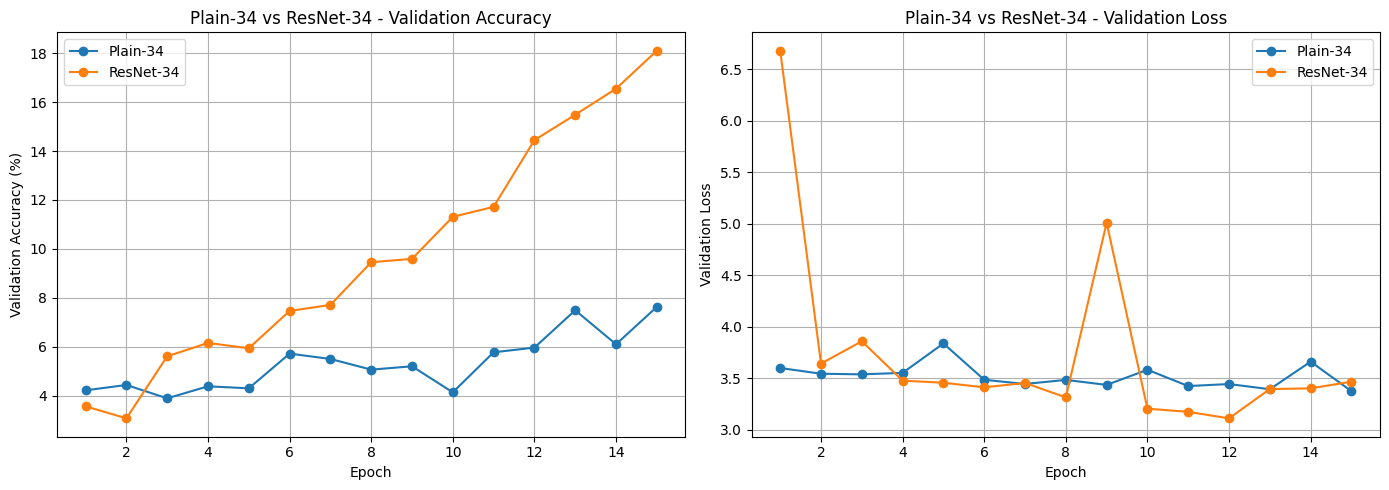

In [123]:
plot_comparison_side_by_side(histories, "Plain-34", "ResNet-34")

왼쪽의 Validation Accuracy 그래프를 한눈에 보아도 ResNet-34의 성능이 눈에 띄게 높은 것을 확인할 수 있다.
ResNet-34와 PlainNet-34 사이에 residual connection 이외의 변수를 배제했으므로 residual connection이 accuracy에 큰 영향을 줌을 알 수 있다.
다만 loss에서는 비슷하거나 일부 구간에서 튀는 모습을 보이는데, 아마 데이터셋이 작아서이거나 epoch가 충분히 많지 않아 발생하는 것으로 추정한다.

---

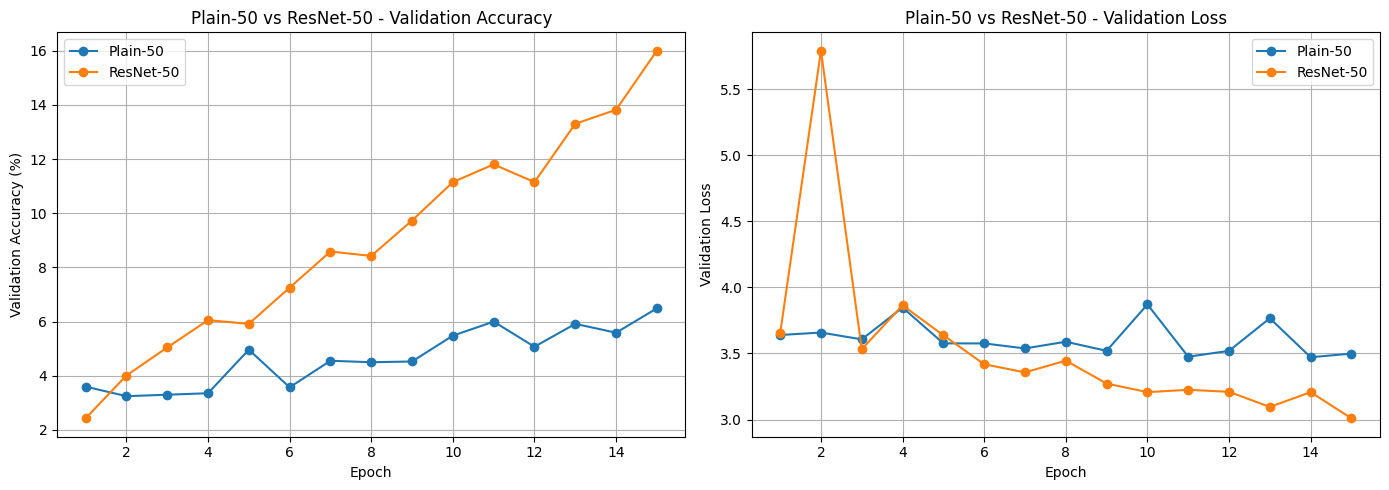

In [124]:
plot_comparison_side_by_side(histories, "Plain-50", "ResNet-50")

ResNet-50 계열의 bottlenect connection에서도 앞서 관측한 residual connection으로 인한 효과가 비슷한 양상을 보이고 있다. 

ResNet-34와 다르게 특기할만한 점은 epoch가 진행될수록 뚜렷하게 보이는 loss의 차이인데 이를 고려함면 더 깊은 구조에서 residual connection의 효과가 더 잘 나타난다고 가정해볼수도 있다.

---


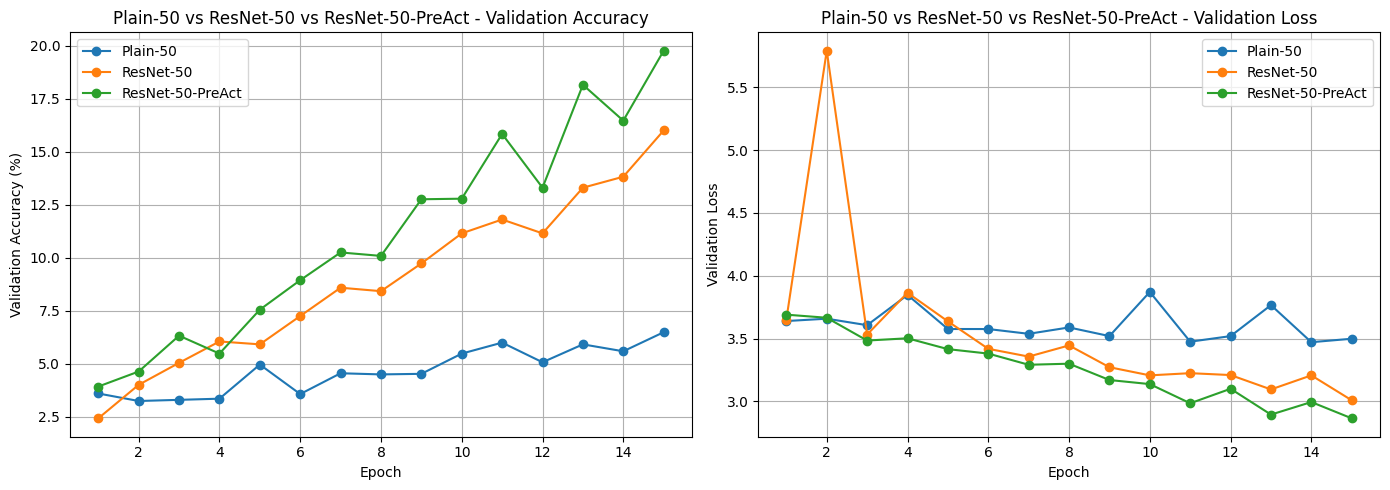

In [126]:
plot_models_side_by_side(
    histories,
    ["Plain-50", "ResNet-50", "ResNet-50-PreAct"],
    title_prefix="Plain-50 vs ResNet-50 vs ResNet-50-PreAct"
)

Identity Mappings in Deep Residual Networks에서 CIFAR-10 분류 오류율이 가장 낮은 것으로 제시되었던 full pre-activation에 대한 학습 및 실험을 같이 진행하였다. full pre-activation Resnet-50은 activation이 convolution의 이전에, 즉 BN->ReLU->Conv의 순서로 진행되는 구조인데, 이 구조는 기존의 ResNet-50보다도 더 뛰어난 성능을 보여주었다. 이로서 BN/ReLU의 위치를 조정하는 것 또한 학습에 긍정적인 영향을 줄 수 있다고 판단하였다. 

--- 

### 결론 및 회고

ResNet 계열 모델의 구조적 요소가 학습 결과에 미치는 영향을 확인하기 위해 세 가지 ablation study를 진행하였다.

첫 번째로 Plain-34와 ResNet-34를 비교하여 기초적인 Basic Block 구조에서 residual connection의 효과를 확인하였다.  
ResNet-34는 Plain-34보다 높은 validation accuracy를 보여, residual connection이 깊은 네트워크의 학습에 긍정적인 영향을 줄 수 있음을 확인하였다.

두 번째로 Plain-50과 ResNet-50을 비교하여 Bottleneck Block 구조에서 residual connection의 효과를 확인하였다.  
Plain-50은 깊이가 증가했음에도 학습 성능이 낮게 나타났지만, ResNet-50은 더 높은 validation accuracy와 낮은 validation loss를 보였다.  
이는 깊은 네트워크에서 residual connection이 degradation 문제를 완화하는 데 도움이 될 수 있음을 보여준다.

세 번째로 ResNet-50과 ResNet-50-PreAct를 비교하여 BN/ReLU 위치 변경의 효과를 확인하였다.  
ResNet-50-PreAct는 ResNet-50보다 더 높은 validation accuracy와 낮은 validation loss를 기록하였다.  
이를 통해 pre-activation 구조가 residual block 내부의 학습 안정성에 긍정적인 영향을 줄 수 있음을 확인하였다.

이번 학습 노드를 통해 ResNet을 직접 구성해보고 residual connection에 대한 실험을 준비하고 진행하며 상당히 많이 스트레스를 받고(p) 그만큼 두루뭉실했던 개념들에 대한 이해도가 많이 올라온것 같았다. 공부 많이 된다. 지금까지 책을 보다가 코드가 나오면 도망가버리고, 이해가 안되면 대충 넘어가다 까먹고 그랬는데 해당 실험 준비과정에서 계속 되돌아와 찾으며 되새김질하는 과정이 도움이 되었다. 사실 gpt 없으면 아무것도 못했을거지만 그렇게 도움받아서라도 진행할수 있었던게 다행인것도 같다. 